# CastMe gradient-ascent unlearning

## 1. Introduction

### 1.1 Dataset and Personal-Data Context

CastMe is a synthetic experimental audition system. Each row is one personal audition submission; repeated rounds can represent callbacks, re-auditions or further takes. Audit-only dates and recorded submission withdrawals support five deletion structures: person, distributed submission, provider/agency, project purpose and retention time. These scenarios support method research rather than proving a specific legal right or regulatory compliance.

### 1.2 Unlearning Objective

For every scenario, gradient-ascent unlearning reloads the same saved seed-42 Original Model and updates it using only the exact Notebook 02 forget records. Retained-validation BCE selects among post-update checkpoints; test results, full-retraining predictions and Forget Quality never select epochs.

### 1.3 Two-Axis Evaluation

**Axis 1 — retained-data utility** compares gradient-ascent unlearning with full retraining on exactly the same retained-test rows. Its five headline metrics are PR-AUC, balanced accuracy, BCE, F1 and AUROC. No composite Utility score is created.

**Axis 2 — CastMe Forget Quality** compares the two models' Classifier Truth Ratio distributions on exactly the same forget-set rows. The KS p-value is the headline score and the KS statistic is supporting evidence. Similarity to full retraining is behavioural evidence, not proof that deleted information is unrecoverable.


## 2. Imports and Setup

### 2.1 Imports

In [1]:
# imports
from __future__ import annotations

import hashlib
import json
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


### 2.2 Reproducibility

Seed 42 controls every random generator. Each scenario resets it before creating its forget-row loader so scenario order cannot change optimisation.

In [2]:
# set seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

Device: mps


### 2.3 Configuration

One fixed configuration is used for all scenarios. Retained-validation BCE selects the best epoch. Forget, retained-test and scenario-matched test results never select epochs or hyperparameters.

In [3]:
# Set the fixed training settings used for every gradient ascent scenario.
GRADIENT_ASCENT_CONFIG = {
    "seed": RANDOM_SEED,
    "learning_rate": 0.00005,
    "maximum_epochs": 10,
    "batch_size": 64,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.0001,
    "optimizer": "AdamW",
    "objective": "negative_forget_set_bce",
    "update_data": "forget_training_rows_only",
    "updated_parameters": "all_mlp_layers",
    "selection_split": "scenario_retained_validation",
    "selection_metric": "binary_cross_entropy",
}
# Set the reproducible bootstrap configuration.
BOOTSTRAP_RESAMPLES = 1_000
BOOTSTRAP_SEED = 2025


### 2.4 File Paths

Paths are centralised and displayed relative to the project code root. Output directories are created before training, while upstream artifacts remain read-only.

In [4]:
# find the main code folder
def locate_code_root(start: Path) -> Path:
    "Find the code root from the notebook or repository working directory."
    for candidate in [start, *start.parents]:
        direct = candidate / "data/processed/castme/castme_auditions_clean.csv"
        nested = candidate / "code/data/processed/castme/castme_auditions_clean.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "code"
    raise FileNotFoundError("Could not locate the CastMe code root.")

CODE_ROOT = locate_code_root(Path.cwd().resolve())
NOTEBOOK_PATHS = [
    CODE_ROOT / "notebooks/CastMe/01_castme_baseline.ipynb",
    CODE_ROOT / "notebooks/CastMe/02_castme_forget_sets_and_full_retraining.ipynb",
    CODE_ROOT / "notebooks/CastMe/03_castme_retain_set_finetuning.ipynb",
]
BASELINE_MANIFEST_PATH = CODE_ROOT / "results/CastMe/configuration/baseline_manifest.json"
DATA_PATH = CODE_ROOT / "data/processed/castme/castme_auditions_clean.csv"
BASELINE_MODEL_PATH = CODE_ROOT / "models/castme/castme_baseline_mlp.pt"
BASELINE_PREPROCESSOR_PATH = CODE_ROOT / "models/castme/castme_preprocessor.joblib"
FULL_MODEL_ROOT = CODE_ROOT / "models/castme/full_retraining"
FULL_RESULTS_ROOT = CODE_ROOT / "results/CastMe/full_retraining"
MODEL_ROOT = CODE_ROOT / "models/castme/gradient_ascent"
RESULTS_ROOT = CODE_ROOT / "results/CastMe/gradient_ascent"


In [5]:
# Define folders for the gradient ascent results.
OUTPUT_DIRS = {
    name: RESULTS_ROOT / name
    for name in ["configuration", "histories", "metrics", "tables", "figures"]
}
# Fix the scenarios and their required order.
EXPECTED_SCENARIO_NAMES = [
    "s1_actor_withdrawal",
    "s2_submission_withdrawal",
    "s3_agency_withdrawal",
    "s4_project_closure",
    "s5_retention_expiry",
]
# Give each scenario its own model folder.
MODEL_DIRECTORIES = {
    name: MODEL_ROOT / name for name in EXPECTED_SCENARIO_NAMES
}
# Create all required model and result folders.
for directory in [MODEL_ROOT, *MODEL_DIRECTORIES.values(), *OUTPUT_DIRS.values()]:
    directory.mkdir(parents=True, exist_ok=True)

# Display the main input and output locations used by this notebook.
display(pd.DataFrame([
    {"artifact": "baseline_model", "path": BASELINE_MODEL_PATH.relative_to(CODE_ROOT)},
    {"artifact": "full_retraining", "path": FULL_MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "gradient_ascent_models", "path": MODEL_ROOT.relative_to(CODE_ROOT)},
    {"artifact": "gradient_ascent_output", "path": RESULTS_ROOT.relative_to(CODE_ROOT)},
]).style.hide(axis="index"))

artifact,path
baseline_model,models/castme/castme_baseline_mlp.pt
full_retraining,models/castme/full_retraining
gradient_ascent_models,models/castme/gradient_ascent
gradient_ascent_output,results/CastMe/gradient_ascent


## 3. Load and Verify Previous Outputs

### 3.1 Load Dataset and Established Split

The exact baseline split arrays and audition identities are loaded from Notebook 01 and verified against its manifest. No partition is reconstructed.


In [6]:
#Create a hash used to check whether a file has changed
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

#Create the same row-index hash used by Notebook 02.
def index_hash(values: np.ndarray) -> str:
    "Return the stable integer-index digest used by Notebook 02."
    return hashlib.sha256(np.asarray(values, dtype=np.int64).tobytes()).hexdigest()

# Load the baseline manifest and cleaned dataset.
baseline_manifest = json.loads(BASELINE_MANIFEST_PATH.read_text())
clean_df = pd.read_csv(DATA_PATH)
target = clean_df["callback"]

# Load the exact saved splits rather than creating new ones.
loaded_splits = {}
for name, artifact in baseline_manifest["split_artifacts"].items():
    index_path, id_path = CODE_ROOT / artifact["index_path"], CODE_ROOT / artifact["audition_id_path"]
    
    # Confirm that the saved split files have not changed.
    assert sha256(index_path) == artifact["index_sha256"]
    assert sha256(id_path) == artifact["audition_id_sha256"]
    loaded_splits[name] = np.load(index_path, allow_pickle=False)
    saved_ids = np.load(id_path, allow_pickle=False)
    
    # Confirm that every saved row position matches its audition ID.
    expected_ids = clean_df.loc[loaded_splits[name], "audition_id"].astype(str).to_numpy(dtype="U")
    assert np.array_equal(saved_ids, expected_ids)

# Recover the original train, validation and test indices.
candidate_train_indices, validation_indices, test_indices = (loaded_splits[name] for name in ["train", "validation", "test"])

# Confirm the expected sizes, no overlap and complete dataset coverage.
split_sets = {name: set(values.tolist()) for name, values in loaded_splits.items()}
assert [len(candidate_train_indices), len(validation_indices), len(test_indices)] == [42_000, 9_000, 9_000]
assert not split_sets["train"] & split_sets["validation"]
assert not split_sets["train"] & split_sets["test"]
assert not split_sets["validation"] & split_sets["test"]
assert set.union(*split_sets.values()) == set(clean_df.index)

# Confirm that the cleaned dataset is unchanged.
assert baseline_manifest["processed_dataset_hash"] == sha256(DATA_PATH)


### 3.2 Load Baseline Artifacts

The threshold, feature order, architecture and hashes come from the saved seed-42 checkpoint; the threshold is never retuned here.

In [7]:
# Load the original model checkpoint.
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)

# Load the original preprocessor while handling possible version warnings.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)

# Record hashes so the baseline artifacts can be checked again later.
BASELINE_MODEL_HASH = sha256(BASELINE_MODEL_PATH)
BASELINE_PREPROCESSOR_HASH = sha256(BASELINE_PREPROCESSOR_PATH)

# Recover the baseline features, threshold, architecture and training settings.
FEATURE_COLUMNS = baseline_checkpoint["feature_columns"]
CONTINUOUS_COLUMNS = baseline_checkpoint["continuous_columns"]
BINARY_COLUMNS = baseline_checkpoint["binary_columns"]
TARGET_COLUMN = "callback"
THRESHOLD = float(baseline_checkpoint["selected_threshold"])
THRESHOLD_LABEL = "fixed_baseline_validation_threshold"
ARCHITECTURE = baseline_checkpoint["architecture"]
BASELINE_HYPERPARAMETERS = baseline_checkpoint["training_hyperparameters"]
RAW_DATASET_HASH = baseline_checkpoint["raw_csv_sha256"]
CLEANED_DATASET_HASH = baseline_checkpoint["cleaned_csv_sha256"]

# Confirm that the baseline configuration is valid.
assert baseline_checkpoint["seed"] == RANDOM_SEED
assert baseline_checkpoint["threshold_selection_split"] == "validation"
assert baseline_preprocessor.get_feature_names_out().tolist() == CONTINUOUS_COLUMNS + BINARY_COLUMNS
assert set(baseline_checkpoint["excluded_metadata_columns"]).isdisjoint(FEATURE_COLUMNS)
print(f"Fixed baseline validation threshold: {THRESHOLD:.2f}")
print(f"Original checkpoint SHA-256: {BASELINE_MODEL_HASH}")

# Note when compatibility checks cover a different saved scikit-learn version.
saved_sklearn_version = baseline_checkpoint["runtime_versions"]["scikit_learn"]
if saved_sklearn_version != sklearn.__version__:
    print(
        "Compatibility check: preprocessors were saved with scikit-learn "
        f"{saved_sklearn_version} and loaded with {sklearn.__version__}; "
        "schema and finite-output checks must pass."
    )


Fixed baseline validation threshold: 0.32
Original checkpoint SHA-256: 4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332


### 3.3 Load Deletion Artifacts

The saved manifest and exact index arrays define the five deletion requests. Forget sets are loaded, never recreated.

In [8]:
# Load the scenario manifest created by Notebook 02.
MANIFEST_PATH = FULL_RESULTS_ROOT / "configuration/scenario_manifest.json"
scenario_manifest = json.loads(MANIFEST_PATH.read_text())

# Recover the scenario definitions and saved statistics.
SCENARIO_NAMES = list(scenario_manifest["scenarios"])
SCENARIOS = scenario_manifest["scenarios"]
SCENARIO_STATS = {
    row["scenario_name"]: row
    for row in scenario_manifest["scenario_statistics"]
}

# Load the exact forget and retain indices for every scenario.
forget_indices = {
    name: np.load(FULL_RESULTS_ROOT / f"forget_indices/{name}_forget_train_indices.npy")
    for name in SCENARIO_NAMES
}
retain_indices = {
    name: np.load(FULL_RESULTS_ROOT / f"retain_indices/{name}_retain_train_indices.npy")
    for name in SCENARIO_NAMES
}
# Confirm that every expected scenario is present and correctly ordered.
assert SCENARIO_NAMES == EXPECTED_SCENARIO_NAMES

### 3.4 Load Full-Retraining Artifacts

Full-retraining models are evaluation references only. Each remains paired with its retain-fitted preprocessor.

In [9]:
# Load each scenario's fully retrained model and preprocessor.
full_checkpoints = {}
full_preprocessors = {}
for scenario_name in SCENARIO_NAMES:
    model_directory = FULL_MODEL_ROOT / scenario_name
    full_checkpoints[scenario_name] = torch.load(
        model_directory / "model.pt", map_location="cpu", weights_only=False
    )
    
    # Suppress version warnings here; later checks verify compatibility.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InconsistentVersionWarning)
        full_preprocessors[scenario_name] = joblib.load(
            model_directory / "preprocessor.joblib"
        )

# Load the full-retraining training results for later comparison.
full_training_summary = pd.read_csv(
    FULL_RESULTS_ROOT / "tables/training_summary.csv"
).set_index("scenario")

In [10]:
# List the notebooks, dataset, baseline files and full-retraining artifacts
# that Notebook 04 must not change.
UPSTREAM_ARTIFACTS = [
    *NOTEBOOK_PATHS, DATA_PATH, BASELINE_MODEL_PATH, BASELINE_PREPROCESSOR_PATH,
    MANIFEST_PATH, FULL_RESULTS_ROOT / "tables/training_summary.csv",
]
# Include every scenario's model, preprocessor, forget indices and retain indices.
for name in SCENARIO_NAMES:
    UPSTREAM_ARTIFACTS.extend([
        FULL_MODEL_ROOT / name / "model.pt",
        FULL_MODEL_ROOT / name / "preprocessor.joblib",
        FULL_RESULTS_ROOT / f"forget_indices/{name}_forget_train_indices.npy",
        FULL_RESULTS_ROOT / f"retain_indices/{name}_retain_train_indices.npy",
    ])
# Record each file's hash before gradient ascent begins.
UPSTREAM_HASHES_BEFORE = {
    str(path.relative_to(CODE_ROOT)): sha256(path) for path in UPSTREAM_ARTIFACTS
}

### 3.5 Integrity Checks

Every required artifact is checked before training. The union of a scenario’s saved forget and retain arrays must exactly equal the reconstructed baseline training partition.

In [11]:
# List every file required before gradient ascent can begin.
required_paths = [
    DATA_PATH, BASELINE_MODEL_PATH, BASELINE_PREPROCESSOR_PATH, MANIFEST_PATH,
    *NOTEBOOK_PATHS,
]
for name in SCENARIO_NAMES:
    required_paths.extend([
        FULL_MODEL_ROOT / name / "model.pt",
        FULL_MODEL_ROOT / name / "preprocessor.joblib",
        FULL_RESULTS_ROOT / f"forget_indices/{name}_forget_train_indices.npy",
        FULL_RESULTS_ROOT / f"retain_indices/{name}_retain_train_indices.npy",
    ])
# Confirm that no required input file is missing.
missing_paths = [artifact for artifact in required_paths if not artifact.is_file()]
assert not missing_paths, missing_paths

# Confirm that the baseline and full-retraining configurations agree.
assert scenario_manifest["threshold"] == THRESHOLD
assert scenario_manifest["baseline_split_artifacts"] == baseline_manifest["split_artifacts"]
assert scenario_manifest["raw_dataset_hash"] == RAW_DATASET_HASH
assert scenario_manifest["cleaned_dataset_hash"] == CLEANED_DATASET_HASH == sha256(DATA_PATH)

# Confirm that the fixed deletion scenario identifiers are unchanged.
assert scenario_manifest["selected_actor_id"] == "A034"
assert scenario_manifest["manager_id"] == "M20"
assert scenario_manifest["film_id"] == "F50"
assert scenario_manifest["retention_cutoff"] == "2021-09-20"

# Confirm that audit metadata remains excluded from model features.
assert scenario_manifest["excluded_metadata_columns"] == baseline_checkpoint["excluded_metadata_columns"]


In [12]:
# Treat the original training indices as the complete population to partition.
train_index_set = set(candidate_train_indices)
verification_rows = []

for name in SCENARIO_NAMES:
    forgotten = set(forget_indices[name])
    retained = set(retain_indices[name])
    stats = SCENARIO_STATS[name]
    reference = full_checkpoints[name]
        
    # Confirm that the forget and retain sets are complete and non-overlapping.
    assert forgotten.isdisjoint(retained)
    assert forgotten | retained == train_index_set
    
    # Confirm that their sizes and hashes match Notebook 02.
    assert len(forgotten) == stats["actual_forget_count"]
    assert len(retained) == stats["retain_count"]
    assert index_hash(forget_indices[name]) == stats["forget_index_hash"]
    assert index_hash(retain_indices[name]) == stats["retain_index_hash"]
    
    # Confirm that the full-retraining reference matches the baseline architecture.
    assert reference["input_dim"] == baseline_checkpoint["input_dim"]
    assert reference["architecture"]["hidden_layer_dimensions"] == ARCHITECTURE["hidden_layer_dimensions"]
    assert reference["architecture"]["dropout_probability"] == ARCHITECTURE["dropout_probability"]
    assert reference["feature_columns"] == FEATURE_COLUMNS
    
    # Confirm that the reference uses the correct scenario and settings.
    assert reference["selected_identifier"] == SCENARIOS[name]["identifier"]
    assert reference["subset_rule"] == SCENARIOS[name]["subset_rule"]
    assert reference["seed"] == RANDOM_SEED
    if "threshold" in reference:
        assert float(reference["threshold"]) == THRESHOLD
    verification_rows.append({
        "scenario": name, "identifier": SCENARIOS[name]["identifier"],
        "requested": stats["requested_percentage"], "achieved": stats["achieved_percentage"],
        "forget_rows": len(forgotten), "retain_rows": len(retained),
        "indices_verified": True, "reference_architecture_verified": True,
    })
# Display the verification outcome for all scenarios.
artifact_verification = pd.DataFrame(verification_rows)
display(artifact_verification.style.hide(axis="index").format({"requested": "{:.2%}", "achieved": "{:.2%}"}))

# Confirm that the actor deletion is not contained within the project deletion.
actor_forget = set(forget_indices["s1_actor_withdrawal"].tolist())
project_forget = set(forget_indices["s4_project_closure"].tolist())
assert not actor_forget.issubset(project_forget)


scenario,identifier,requested,achieved,forget_rows,retain_rows,indices_verified,reference_architecture_verified
s1_actor_withdrawal,A034,1.00%,0.99%,415,41585,True,True
s2_submission_withdrawal,True,5.00%,5.09%,2137,39863,True,True
s3_agency_withdrawal,M20,10.00%,10.06%,4224,37776,True,True
s4_project_closure,F50,15.00%,14.97%,6289,35711,True,True
s5_retention_expiry,2021-09-20,15.00%,15.00%,6298,35702,True,True


### 3.6 Prepare Raw Partitions

Raw rows are kept as the common comparison basis. The canonical preprocessor transforms Original and gradient-ascent inputs; each full-retraining preprocessor transforms the same rows for its paired reference model.

In [13]:
# Separate model features from audit metadata.
features = clean_df[FEATURE_COLUMNS]
metadata = clean_df[baseline_checkpoint["excluded_metadata_columns"]].copy()
metadata["audition_date"] = pd.to_datetime(metadata["audition_date"], format="%Y-%m-%d", errors="raise")


def scenario_mask(frame: pd.DataFrame, scenario: dict[str, object]) -> pd.Series:
    #Identify records that match one deletion rule.
    if scenario["rule_type"] == "equals":
        return frame[scenario["column"]].eq(scenario["identifier"])
    if scenario["rule_type"] == "boolean_true":
        return frame[scenario["column"]].eq(True)
    if scenario["rule_type"] == "date_before":
        return frame[scenario["column"]].lt(pd.Timestamp(scenario["identifier"]))
    raise ValueError(f"Unsupported rule type: {scenario['rule_type']}")

# Prepare the retained and matching data partitions for each scenario.
scenario_data = {}
for name in SCENARIO_NAMES:
    validation_match = scenario_mask(metadata.loc[validation_indices], SCENARIOS[name])
    test_match = scenario_mask(metadata.loc[test_indices], SCENARIOS[name])
    scenario_data[name] = {
        # Retained training records support partition checks only.
        "retain_train_x": features.loc[retain_indices[name]],
        "retain_train_y": target.loc[retain_indices[name]],
        
        # Non-matching validation records are used for early stopping.
        "retain_validation_x": features.loc[validation_match.index[~validation_match]],
        "retain_validation_y": target.loc[validation_match.index[~validation_match]],
        
        # Non-matching test records measure retained-set utility.
        "retain_test_x": features.loc[test_match.index[~test_match]],
        "retain_test_y": target.loc[test_match.index[~test_match]],
        
        # Actor-role groups are preserved for clustered bootstrapping.
        "retain_test_clusters": metadata.loc[test_match.index[~test_match], ["actor_id", "role_id"]].astype(str).agg("|".join, axis=1).to_numpy(),
        
        # Matching test records support additional descriptive evaluation.
        "matched_test_x": features.loc[test_match.index[test_match]],
        "matched_test_y": target.loc[test_match.index[test_match]],

        # Deleted training records drive gradient ascent and forget-set evaluation.
        "forget_x": features.loc[forget_indices[name]],
        "forget_y": target.loc[forget_indices[name]],
    }


## 4. Gradient-Ascent Unlearning Method

### 4.1 Method Definition

Ordinary training minimises forget-set BCE. Gradient ascent deliberately increases it by minimising its negative: `gradient_ascent_objective = -forget_bce`. Only forget training rows drive updates; adding retained rows would instead create gradient difference.

All MLP layers use AdamW with one conservative learning rate of `0.00005` and the same fixed budget in every scenario. The frozen baseline preprocessor preserves the input representation expected by the saved Original Model. Pure gradient ascent can damage retained utility or become unstable, so retained-validation BCE protects checkpoint selection and finite-value checks stop unsafe runs. This remains approximate unlearning, not proof of deletion.


In [14]:
# Recreate the neural network used by the baseline model.
class CastMeMLP(nn.Module):
    "Baseline-compatible CastMe MLP."

    def __init__(self, input_dim: int) -> None:
        super().__init__()
        # Load the original hidden-layer sizes.
        hidden_one, hidden_two = ARCHITECTURE["hidden_layer_dimensions"]
        
        # Recreate the baseline architecture exactly.
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_one), nn.ReLU(),
            nn.Dropout(ARCHITECTURE["dropout_probability"]),
            nn.Linear(hidden_one, hidden_two), nn.ReLU(),
            nn.Linear(hidden_two, 1),
        )
    # Return one raw prediction score for each record.
    def forward(self, values: torch.Tensor) -> torch.Tensor:
        return self.network(values).squeeze(1)

### 4.2 Small Helper Functions

#### 4.2.1 Fresh Baseline Loading

Reloading from disk inside every scenario prevents sequential gradient ascent or hidden in-memory state.

In [15]:
# Create a reproducible hash of a model's weights.
def state_dict_hash(state_dict: dict[str, torch.Tensor]) -> str:
    "Hash tensor names, dtypes, shapes and bytes deterministically."
    digest = hashlib.sha256()

    # Include every tensor's name, type, shape and values in a fixed order.
    for key in sorted(state_dict):
        tensor = state_dict[key].detach().cpu().contiguous()
        digest.update(key.encode())
        digest.update(str(tensor.dtype).encode())
        digest.update(np.asarray(tensor.shape, dtype=np.int64).tobytes())
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()

# Record the original baseline weight hash.
BASELINE_STATE_HASH = state_dict_hash(baseline_checkpoint["state_dict"])


def load_fresh_baseline_model() -> tuple[nn.Module, str]:
    "Reload and verify a fresh copy of the saved Original Model."
    # Reload from disk so scenarios cannot share updated weights.
    checkpoint = torch.load(BASELINE_MODEL_PATH, map_location="cpu", weights_only=False)
    
    # Confirm that the checkpoint file and its model weights are unchanged.
    assert sha256(BASELINE_MODEL_PATH) == BASELINE_MODEL_HASH
    assert state_dict_hash(checkpoint["state_dict"]) == BASELINE_STATE_HASH
    
    # Recreate the model and load the verified baseline weights.
    model = CastMeMLP(checkpoint["input_dim"])
    model.load_state_dict(checkpoint["state_dict"])
    return model.to(DEVICE), state_dict_hash(model.state_dict())

#### 4.2.2 Data Loaders

Only forget training rows enter the shuffled update loader. Retained validation rows are evaluated without updates and protect utility during checkpoint selection.


In [16]:
# Transform features and create a reproducible DataLoader.
def make_loader(
    raw_features: pd.DataFrame,
    labels: pd.Series,
    *,
    shuffle: bool,
) -> DataLoader:
    "Transform with the frozen baseline preprocessor and create a loader."
    # Use the frozen baseline preprocessor without refitting it.
    processed = baseline_preprocessor.transform(raw_features).astype(np.float32)
    
    # Combine the processed features and labels into one dataset.
    dataset = TensorDataset(
        torch.tensor(processed),
        torch.tensor(labels.to_numpy(), dtype=torch.float32),
    )
    # Load the data in reproducible batches.
    return DataLoader(
        dataset,
        batch_size=GRADIENT_ASCENT_CONFIG["batch_size"],
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(RANDOM_SEED),
    )

#### 4.2.3 Validation BCE

In [17]:
# Calculate average BCE loss without updating the model.
def average_bce(model: nn.Module, loader: DataLoader) -> float:
    "Calculate row-weighted BCE without updating parameters."
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    loss_sum, row_count = 0.0, 0
    
    # Disable gradients because this function only evaluates the model.
    with torch.no_grad():
        for batch_x, batch_y in loader:
            loss = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
            
            # Weight the batch loss by its number of records.
            loss_sum += loss.item() * len(batch_y)
            row_count += len(batch_y)
    return loss_sum / row_count

#### 4.2.4 One Training Epoch

In [18]:
def gradient_ascent_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> float:
    "Increase BCE for one epoch of forget-set records."
    # Only deleted training records are included in this loader.
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    loss_sum, row_count = 0.0, 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        forget_bce = criterion(model(batch_x.to(DEVICE)), batch_y.to(DEVICE))
        if not torch.isfinite(forget_bce):
            raise FloatingPointError("Non-finite forget-set BCE detected.")
        gradient_ascent_objective = -forget_bce
        gradient_ascent_objective.backward()
        optimizer.step()
        if not all(torch.isfinite(parameter).all() for parameter in model.parameters()):
            raise FloatingPointError("Non-finite model parameter detected.")
        loss_sum += forget_bce.item() * len(batch_y)
        row_count += len(batch_y)
    return loss_sum / row_count

#### 4.2.5 Training Helper

Retained-validation BCE selects and restores the best post-update checkpoint. Epoch zero is never eligible. Forget rows drive the ascent objective, while test results, full-retraining outputs and Forget Quality are absent from checkpoint selection.

In [19]:
def gradient_ascent_scenario(scenario_name: str) -> dict[str, object]:
    "Apply pure forget-set gradient ascent to a fresh baseline copy."
    
    # Reset randomness so every scenario is reproducible.
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)
    
    # Reload the untouched baseline so every scenario starts identically.
    model, starting_state_hash = load_fresh_baseline_model()
    data = scenario_data[scenario_name]
    
    # Create the forget-only update loader and retained-validation loader.
    forget_loader = make_loader(data["forget_x"], data["forget_y"], shuffle=True)
    validation_loader = make_loader(
        data["retain_validation_x"], data["retain_validation_y"], shuffle=False
    )
    
    # Use the gradient ascent learning rate and baseline weight decay.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=GRADIENT_ASCENT_CONFIG["learning_rate"],
        weight_decay=BASELINE_HYPERPARAMETERS["weight_decay"],
    )
    best_loss, best_epoch, stale_epochs, best_state = float("inf"), 0, 0, None
    history_rows = []
    started = time.perf_counter()
    # Select the best checkpoint using retained-validation BCE only.
    for epoch in range(1, GRADIENT_ASCENT_CONFIG["maximum_epochs"] + 1):
        forget_bce = gradient_ascent_epoch(model, forget_loader, optimizer)
        validation_loss = average_bce(model, validation_loader)
        if not np.isfinite(validation_loss):
            raise FloatingPointError("Non-finite retained-validation BCE detected.")
        history_rows.append({
            "epoch": epoch, "forget_bce": forget_bce,
            "retained_validation_bce": validation_loss,
        })
        
        # Save the weights when validation loss improves sufficiently.
        if validation_loss < best_loss - GRADIENT_ASCENT_CONFIG["early_stopping_min_delta"]:
            best_loss, best_epoch, stale_epochs = validation_loss, epoch, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            stale_epochs += 1
        
        # Stop when validation loss has not improved for four epochs.
        if stale_epochs >= GRADIENT_ASCENT_CONFIG["early_stopping_patience"]:
            break
    runtime_seconds = time.perf_counter() - started
    assert best_state is not None and best_epoch >= 1
    
    # Restore the weights from the best validation epoch.
    model.load_state_dict(best_state)
    return {
        "model": model.to(DEVICE), "history": pd.DataFrame(history_rows),
        "starting_model_hash": BASELINE_MODEL_HASH, "starting_state_hash": starting_state_hash,
        "epochs_completed": epoch, "best_epoch": best_epoch,
        "best_validation_bce": best_loss, "runtime_seconds": runtime_seconds,
        "checkpoint_is_post_update": True,
        "update_row_count": len(data["forget_y"]),
        "update_index_hash": index_hash(forget_indices[scenario_name]),
    }

#### 4.2.6 Probability and Metric Helpers

In [20]:
def predict_raw(
    model: nn.Module,
    preprocessor,
    raw_features: pd.DataFrame,
) -> np.ndarray:
    "Generate finite probabilities using the model's paired preprocessor."
    # Transform the features using the preprocessor fitted for this model.
    processed = preprocessor.transform(raw_features).astype(np.float32)
    
    # Generate predictions without updating the model.
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(processed, device=next(model.parameters()).device))
    
    # Convert raw outputs into probabilities and check they are valid.
    probabilities = torch.sigmoid(logits).cpu().numpy()
    assert np.isfinite(probabilities).all()
    return probabilities


def load_reference_model(scenario_name: str) -> nn.Module:
    "Load a full-retraining checkpoint for evaluation only."
    checkpoint = full_checkpoints[scenario_name]
    
    # Recreate the model and load its saved full-retraining weights.
    model = CastMeMLP(checkpoint["input_dim"])
    model.load_state_dict(checkpoint["state_dict"])
    return model.to(DEVICE).eval()

In [21]:
def classification_metrics(y_true: pd.Series, probabilities: np.ndarray) -> dict[str, object]:
    "Calculate utility metrics at the fixed baseline threshold."
    
    # Avoid exact probabilities of 0 or 1 for stable loss calculation.
    probabilities = np.clip(probabilities.astype(float), 1e-7, 1 - 1e-7)
    
    # Convert probabilities into callback predictions.
    predictions = (probabilities >= THRESHOLD).astype(int)
    
    # Use the confusion matrix to calculate specificity.
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    true_negative, false_positive, _, _ = matrix.ravel()
    
    # Return classification and probability-based performance metrics.
    return {
        "auroc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "bce": log_loss(y_true, probabilities, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, probabilities),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "confusion_matrix": matrix.tolist(),
    }

### 4.3 Five Independent Scenario Executions

The loop below reloads the same Original Model checkpoint inside every scenario call. Gradient ascent models therefore never inherit another scenario's updates.


#### 4.3.1 Forget-Only Gradient-Ascent Runs

In [22]:
# Apply forget-only gradient ascent to a fresh baseline for every scenario.
gradient_ascent_runs = {}
for scenario_name in SCENARIO_NAMES:
    gradient_ascent_runs[scenario_name] = gradient_ascent_scenario(scenario_name)
    
    # Report the best and final epoch for each run.
    print(
        f"{SCENARIOS[scenario_name]['display_name']}: "
        f"best epoch {gradient_ascent_runs[scenario_name]['best_epoch']}, "
        f"completed {gradient_ascent_runs[scenario_name]['epochs_completed']}"
    )

# Combine and display the training histories for all scenarios.
display(pd.concat(
    [run["history"].assign(scenario=name) for name, run in gradient_ascent_runs.items()],
    ignore_index=True,
).style.hide(axis="index").format(precision=6))


Actor withdrawal — 1%: best epoch 1, completed 5
Submission withdrawal — 5%: best epoch 1, completed 5
Agency withdrawal — 10%: best epoch 1, completed 5
Project closure — 15%: best epoch 1, completed 5
Retention expiry — 15%: best epoch 1, completed 5


epoch,forget_bce,retained_validation_bce,scenario
1,0.429772,0.542441,s1_actor_withdrawal
2,0.432452,0.542468,s1_actor_withdrawal
3,0.434309,0.542489,s1_actor_withdrawal
4,0.433682,0.542514,s1_actor_withdrawal
5,0.431922,0.542540,s1_actor_withdrawal
1,0.561072,0.540787,s2_submission_withdrawal
2,0.565237,0.540789,s2_submission_withdrawal
3,0.562429,0.540775,s2_submission_withdrawal
4,0.564460,0.540776,s2_submission_withdrawal
5,0.560265,0.540788,s2_submission_withdrawal


### 4.4 Training Summary

In [23]:
# Collect the main training details for every scenario.
training_summary = pd.DataFrame([
    {
        "scenario": name,
        "requested_deletion_percentage": SCENARIO_STATS[name]["requested_percentage"],
        "achieved_deletion_percentage": SCENARIO_STATS[name]["achieved_percentage"],
        "retain_rows": len(retain_indices[name]),
        "forget_rows": len(forget_indices[name]),
        "starting_model_hash": run["starting_model_hash"],
        "seed": RANDOM_SEED,
        "learning_rate": GRADIENT_ASCENT_CONFIG["learning_rate"],
        "epochs_completed": run["epochs_completed"],
        "best_epoch": run["best_epoch"],
        "best_retained_validation_bce": run["best_validation_bce"],
        "runtime_seconds": run["runtime_seconds"],
        "update_rows": run["update_row_count"],
        "update_index_hash": run["update_index_hash"],
        "checkpoint_is_post_update": run["checkpoint_is_post_update"],
    }
    for name, run in gradient_ascent_runs.items()
])

# Confirm that every scenario started from the same baseline file and weights.
assert training_summary["starting_model_hash"].nunique() == 1
assert all(run["starting_state_hash"] == BASELINE_STATE_HASH for run in gradient_ascent_runs.values())
assert all(
    state_dict_hash(run["model"].state_dict()) != BASELINE_STATE_HASH
    for run in gradient_ascent_runs.values()
)
assert training_summary["checkpoint_is_post_update"].all()
assert training_summary["update_rows"].eq(training_summary["forget_rows"]).all()
assert all(
    row.update_index_hash == index_hash(forget_indices[row.scenario])
    for row in training_summary.itertuples(index=False)
)

# Display the gradient ascent configuration and outcome for each scenario.
display(training_summary.style.hide(axis="index").format({
    "requested_deletion_percentage": "{:.2%}", "achieved_deletion_percentage": "{:.2%}",
    "learning_rate": "{:.5f}", "best_retained_validation_bce": "{:.6f}", "runtime_seconds": "{:.2f}",
}))

scenario,requested_deletion_percentage,achieved_deletion_percentage,retain_rows,forget_rows,starting_model_hash,seed,learning_rate,epochs_completed,best_epoch,best_retained_validation_bce,runtime_seconds,update_rows,update_index_hash,checkpoint_is_post_update
s1_actor_withdrawal,1.00%,0.99%,41585,415,4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332,42,0.00005,5,1,0.542441,1.39,415,449f49a945f17e7520a6acaf7c045ebad6182f232f0f1d207d9dde5870f274fc,True
s2_submission_withdrawal,5.00%,5.09%,39863,2137,4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332,42,0.00005,5,1,0.540787,1.80,2137,afc107162fcdc1785e323e471043c313095eaf225e2970597f2d1fddc0dc914a,True
s3_agency_withdrawal,10.00%,10.06%,37776,4224,4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332,42,0.00005,5,1,0.542645,2.54,4224,36ea57196e9631102215372f798974959d525a925d04c4f319f573758c8db5ee,True
s4_project_closure,15.00%,14.97%,35711,6289,4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332,42,0.00005,5,1,0.544804,3.12,6289,813382c90d85b86a1ba7fcb633a239f3e1f24fe8e25cb91449ed6c187aeb4f1c,True
s5_retention_expiry,15.00%,15.00%,35702,6298,4f7757e504911e6411983a911001e9aea9eef15fd7268fac71c84b0bc1cc7332,42,0.00005,5,1,0.543614,3.23,6298,21d7ae905af7e65c8e2600b09673185250d7b3e5c3f4d87f513b8fd5bf1f8c40,True


#### 4.4.1 Findings

- All five scenarios reload identical Original Model weights and update only their saved forget training rows.
- Every selected checkpoint follows at least one gradient-ascent update; epoch-zero Original Model weights are never eligible.
- Retained-validation BCE protects utility during selection but does not guarantee successful forgetting.


## 5. Evaluation Datasets

### 5.1 Primary Forget Set

The primary forget set contains the saved training rows covered by each deletion request. These records influenced the Original Model and are the only rows used for gradient-ascent updates.

### 5.2 Primary Utility Set

Primary utility uses the same scenario-specific retained test rows as Notebook 02. Test rows satisfying the relevant deletion condition are excluded.

### 5.3 Supporting Behavioural Set

Supporting matched-test rows satisfy the relevant scenario condition: actor identity, submission-withdrawal flag, agency identity, project identity, or retention cutoff. They were not deleted training records and are used only for descriptive evaluation of behaviour on condition-matched held-out rows.


In [24]:
# Record the size of each evaluation group for every scenario.
evaluation_set_summary = pd.DataFrame([
    {
        "scenario": name,
        "forget_training_rows": len(data["forget_y"]),
        "retained_test_rows": len(data["retain_test_y"]),
        "scenario_matched_test_rows": len(data["matched_test_y"]),
    }
    for name, data in scenario_data.items()
])

# Display the number of records available for each evaluation.
display(evaluation_set_summary.style.hide(axis="index").format({
    "forget_training_rows": "{:,.0f}", "retained_test_rows": "{:,.0f}",
    "scenario_matched_test_rows": "{:,.0f}",
}))

scenario,forget_training_rows,retained_test_rows,scenario_matched_test_rows
s1_actor_withdrawal,415,"8,920",80
s2_submission_withdrawal,"2,137","8,590",410
s3_agency_withdrawal,"4,224","8,079",921
s4_project_closure,"6,289","7,616","1,384"
s5_retention_expiry,"6,298","7,681","1,319"


## 6. Axis 1: Retained-Data Utility

Utility is measured on retained test rows shared exactly by gradient-ascent unlearning and full retraining. PR-AUC and AUROC evaluate probability ranking; balanced accuracy and F1 use the fixed threshold of 0.32; BCE evaluates probability quality and is lower when predictions are better. No composite Utility score is created.

In [25]:
# Keep one verified Original Model for supplementary forget-set context only.
baseline_model, _ = load_fresh_baseline_model()
prediction_cache = {}
utility_rows = []
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    
    # Load the scenario's full-retraining reference model.
    reference_model = load_reference_model(name)
    
    # Compare only gradient ascent and full retraining on identical retained test rows.
    prediction_cache[name] = {
        "gradient_ascent": predict_raw(gradient_ascent_runs[name]["model"], baseline_preprocessor, data["retain_test_x"]),
        "full_retraining": predict_raw(reference_model, full_preprocessors[name], data["retain_test_x"]),
    }
    # Calculate utility metrics using the fixed baseline threshold.
    for model_name, probabilities in prediction_cache[name].items():
        utility_rows.append({
            "scenario": name, "model": model_name,
            "retained_test_rows": len(data["retain_test_y"]),
            "threshold": THRESHOLD, "threshold_label": THRESHOLD_LABEL,
            **classification_metrics(data["retain_test_y"], probabilities),
        })
utility_metrics = pd.DataFrame(utility_rows)
SCENARIO_DISPLAY = {name: SCENARIOS[name]["display_name"] for name in SCENARIO_NAMES}
MODEL_DISPLAY = {
    "gradient_ascent": "Gradient-ascent unlearning",
    "full_retraining": "Full retraining",
}

# Present only the two post-deletion models and five headline utility metrics.
primary_utility_metrics = utility_metrics.query(
    "model in ['gradient_ascent', 'full_retraining']"
)[["scenario", "model", "pr_auc", "balanced_accuracy", "bce", "f1", "auroc"]].copy()
primary_utility_table = primary_utility_metrics.copy()
primary_utility_table["scenario"] = primary_utility_table["scenario"].map(SCENARIO_DISPLAY)
primary_utility_table["model"] = primary_utility_table["model"].map(MODEL_DISPLAY)
primary_utility_table.columns = [
    "Scenario", "Model", "PR-AUC", "Balanced Accuracy", "BCE", "F1", "AUROC"
]
display(primary_utility_table.style.hide(axis="index").format(precision=4))

Scenario,Model,PR-AUC,Balanced Accuracy,BCE,F1,AUROC
Actor withdrawal — 1%,Gradient-ascent unlearning,0.6268,0.6970,0.5470,0.6346,0.7678
Actor withdrawal — 1%,Full retraining,0.6252,0.6980,0.5474,0.6339,0.7678
Submission withdrawal — 5%,Gradient-ascent unlearning,0.6278,0.6957,0.5471,0.6329,0.7677
Submission withdrawal — 5%,Full retraining,0.6270,0.6988,0.5474,0.6344,0.7676
Agency withdrawal — 10%,Gradient-ascent unlearning,0.6317,0.7018,0.5447,0.6409,0.7715
Agency withdrawal — 10%,Full retraining,0.6315,0.7026,0.5443,0.6416,0.7720
Project closure — 15%,Gradient-ascent unlearning,0.6362,0.7004,0.5478,0.6454,0.7706
Project closure — 15%,Full retraining,0.6380,0.7021,0.5471,0.6457,0.7714
Retention expiry — 15%,Gradient-ascent unlearning,0.6316,0.7000,0.5433,0.6373,0.7720
Retention expiry — 15%,Full retraining,0.6318,0.7016,0.5433,0.6358,0.7727


### 6.1 Utility Gaps to Full Retraining

In [26]:
# Calculate differences for the five headline utility metrics only.
HEADLINE_UTILITY_METRICS = ["pr_auc", "balanced_accuracy", "bce", "f1", "auroc"]
UTILITY_GAP_METRICS = HEADLINE_UTILITY_METRICS
utility_gap_rows = []
for name in SCENARIO_NAMES:

    # Arrange both post-deletion models' results for this scenario.
    scenario_rows = utility_metrics.query("scenario == @name").set_index("model")
    
    # Treat full retraining as the reference result.
    reference = scenario_rows.loc["full_retraining"]
    
    # Subtract full retraining from gradient-ascent unlearning.
    for model_name in ["gradient_ascent"]:
        utility_gap_rows.append({
            "scenario": name,
            "model": model_name,
            **{
                f"{metric}_gap_to_full_retraining": scenario_rows.loc[model_name, metric] - reference[metric]
                for metric in UTILITY_GAP_METRICS
            },
        })
utility_gaps = pd.DataFrame(utility_gap_rows)
utility_difference_summary = utility_gaps.copy()
utility_difference_summary["scenario"] = utility_difference_summary["scenario"].map(SCENARIO_DISPLAY)
utility_difference_summary["model"] = utility_difference_summary["model"].map(MODEL_DISPLAY)

### 6.2 Paired Actor–Role Cluster Bootstrap Confidence Intervals

These intervals use 1,000 deterministic paired actor–role cluster resamples. The same sampled clusters index both models. They quantify uncertainty from retained-test observations, not model-training variability from the single training seed.


In [27]:
def paired_actor_role_cluster_bootstrap(
    labels: pd.Series, clusters: np.ndarray, fine_probabilities: np.ndarray,
    reference_probabilities: np.ndarray, seed: int,
) -> tuple[list[dict[str, float]], int]:
    "Sample actor-role clusters once and apply each sample to both models."
    
    # Set up reproducible sampling and identify actor-role groups.
    rng, y_values = np.random.default_rng(seed), labels.to_numpy()
    unique_clusters = np.unique(clusters)
    
    # Store the row positions belonging to each actor-role pair.
    cluster_positions = {key: np.flatnonzero(clusters == key) for key in unique_clusters}
    rows = []
    for _ in range(BOOTSTRAP_RESAMPLES):
        
        # Evaluate both models on exactly the same sampled records.
        sampled = rng.choice(unique_clusters, size=len(unique_clusters), replace=True)
        positions = np.concatenate([cluster_positions[key] for key in sampled])
        
        # Skip samples that contain only one callback outcome.
        if np.unique(y_values[positions]).size < 2:
            continue
        fine = classification_metrics(pd.Series(y_values[positions]), fine_probabilities[positions])
        full = classification_metrics(pd.Series(y_values[positions]), reference_probabilities[positions])
        
        # Store gradient ascent minus full-retraining differences.
        rows.append({
            metric: fine[metric] - full[metric]
            for metric in HEADLINE_UTILITY_METRICS
        })
    return rows, len(unique_clusters)


In [28]:
# Estimate uncertainty in gradient ascent versus full-retraining utility gaps.
utility_ci_rows = []
for scenario_position, name in enumerate(SCENARIO_NAMES):

    # Run a paired cluster bootstrap using a reproducible scenario-specific seed.
    rows, unique_cluster_count = paired_actor_role_cluster_bootstrap(
        scenario_data[name]["retain_test_y"], scenario_data[name]["retain_test_clusters"],
        prediction_cache[name]["gradient_ascent"], prediction_cache[name]["full_retraining"],
        BOOTSTRAP_SEED + scenario_position,
    )
    bootstrap = pd.DataFrame(rows)
    for metric in HEADLINE_UTILITY_METRICS:
        
        # Retrieve the observed gradient ascent minus full-retraining difference.
        point = utility_gaps.query("scenario == @name and model == 'gradient_ascent'")[f"{metric}_gap_to_full_retraining"].iloc[0]
        
        # Calculate the central 95% bootstrap interval.
        utility_ci_rows.append({
            "scenario": name, "metric": metric, "point_difference": point,
            "ci_lower": bootstrap[metric].quantile(0.025), "ci_upper": bootstrap[metric].quantile(0.975),
            "valid_resamples": len(bootstrap), "unique_cluster_count": unique_cluster_count,
            "bootstrap_method": "paired_actor_role_cluster_bootstrap",
        })
utility_difference_cis = pd.DataFrame(utility_ci_rows)


### 6.3 Utility Findings

In [29]:
# Mark whether each confidence interval contains zero.
utility_interval_summary = utility_difference_cis.assign(
    includes_zero=(utility_difference_cis["ci_lower"] <= 0)
    & (utility_difference_cis["ci_upper"] >= 0)
)

# Confirm that every requested bootstrap sample was valid.
assert utility_interval_summary["valid_resamples"].eq(BOOTSTRAP_RESAMPLES).all()

# Keep interval results for the later utility-difference section.


- Utility differences and paired cluster intervals are reported after the primary Forget Quality table.
- The intervals quantify retained-test observation uncertainty, not training variability from the single seed.
- Strong utility preservation does not itself demonstrate forgetting.


## 7. Axis 2: CastMe Forget Quality

For each forget-set record, the Classifier Truth Ratio is `(1 - p_correct) / p_correct`, where `p_correct = y p + (1-y)(1-p)` and is clipped by a small numerical epsilon before division. Values below 1 favour the correct class, 1 gives both classes equal probability, and values above 1 favour the incorrect class. It is mathematically related to per-record BCE by `Classifier Truth Ratio = exp(BCE) - 1`. This classifier-specific adaptation is inspired by TOFU, but it is not TOFU's original generative Truth Ratio.

The same forget records are scored by gradient-ascent unlearning and full retraining. A two-sample KS test compares their Truth Ratio distributions. The KS p-value is the headline Forget Quality score: higher means the test found less evidence of distinguishable behaviour. The KS statistic is supporting evidence and is lower when distributions are closer. This TOFU-inspired distributional comparison does not use the natural pairing of predictions on identical records.

In [30]:
TRUTH_RATIO_EPSILON = 1e-7
TRUTH_RATIO_DEFINITION = "(1 - p_correct) / p_correct, where p_correct = y*p + (1-y)*(1-p)"


def per_example_loss(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    "Return clipped binary cross-entropy for each example."
    y_values = labels.to_numpy(dtype=float)
    
    # Avoid taking the logarithm of exactly zero.
    probabilities = np.clip(probabilities.astype(float), TRUTH_RATIO_EPSILON, 1 - TRUTH_RATIO_EPSILON)
    return -(y_values * np.log(probabilities) + (1 - y_values) * np.log(1 - probabilities))


def true_label_confidence(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    "Return probability assigned to each record's observed label."
    y_values = labels.to_numpy(dtype=float)
    
    # Use callback probability for label 1 and no-callback probability for label 0.
    return y_values * probabilities + (1 - y_values) * (1 - probabilities)


def classifier_truth_ratio(labels: pd.Series, probabilities: np.ndarray) -> np.ndarray:
    "Return the odds against the observed class for each record."
    correct_probability = true_label_confidence(labels, probabilities)
    correct_probability = np.clip(
        correct_probability, TRUTH_RATIO_EPSILON, 1 - TRUTH_RATIO_EPSILON
    )
    ratios = (1 - correct_probability) / correct_probability
    assert np.isfinite(ratios).all() and (ratios >= 0).all()
    return ratios


def reference_normalised_score(distance: float, original_distance: float) -> float:
    "Map full retraining to one and the Original Model to zero without clipping."
    
    # Avoid division by a value that is effectively zero.
    if original_distance < 1e-8:
        return np.nan
    return 1 - distance / original_distance

In [31]:
# Compare all models on the deleted training records.
forget_prediction_cache = {}
forgetfulness_rows = []
forget_quality_rows = []
assert GRADIENT_ASCENT_CONFIG["selection_split"] == "scenario_retained_validation"
assert THRESHOLD == float(baseline_checkpoint["selected_threshold"]) == 0.32
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    reference_model = load_reference_model(name)
    assert np.array_equal(data["forget_x"].index.to_numpy(), forget_indices[name])
    assert np.array_equal(data["retain_train_x"].index.to_numpy(), retain_indices[name])
    assert set(data["forget_x"].index).isdisjoint(data["retain_train_x"].index)
    assert set(data["retain_test_x"].index).isdisjoint(train_index_set)
    assert full_checkpoints[name]["forget_index_hash"] == index_hash(forget_indices[name])
    
    # Generate forget-set predictions from all three models.
    probabilities_by_model = {
        "original": predict_raw(baseline_model, baseline_preprocessor, data["forget_x"]),
        "gradient_ascent": predict_raw(gradient_ascent_runs[name]["model"], baseline_preprocessor, data["forget_x"]),
        "full_retraining": predict_raw(reference_model, full_preprocessors[name], data["forget_x"]),
    }
    forget_prediction_cache[name] = probabilities_by_model
    
    # Treat full retraining as the target behaviour.
    reference = probabilities_by_model["full_retraining"]
    original_distance = np.abs(probabilities_by_model["original"] - reference).mean()
    reference_loss = per_example_loss(data["forget_y"], reference)
    reference_confidence = true_label_confidence(data["forget_y"], reference)
    reference_truth_ratios = classifier_truth_ratio(data["forget_y"], reference)
    for model_name, probabilities in probabilities_by_model.items():
        losses = per_example_loss(data["forget_y"], probabilities)
        confidence = true_label_confidence(data["forget_y"], probabilities)
        truth_ratios = classifier_truth_ratio(data["forget_y"], probabilities)
        distance = np.abs(probabilities - reference).mean()
        assert np.allclose(truth_ratios, np.expm1(losses), rtol=1e-6, atol=1e-7)
        
        # Compare Classifier Truth Ratio distributions with full retraining.
        ks_result = ks_2samp(truth_ratios, reference_truth_ratios, method="auto")
        assert 0 <= ks_result.pvalue <= 1 and 0 <= ks_result.statistic <= 1
        if model_name == "full_retraining":
            assert ks_result.statistic == 0 and ks_result.pvalue == 1
        forgetfulness_rows.append({
            "scenario": name, "model": model_name, "forget_rows": len(data["forget_y"]),
            "mean_absolute_probability_difference_from_full": distance,
            "absolute_bce_difference_from_full": abs(losses.mean() - reference_loss.mean()),
            "prediction_agreement_with_full": ((probabilities >= THRESHOLD) == (reference >= THRESHOLD)).mean(),
            "mean_true_label_confidence_difference_from_full": confidence.mean() - reference_confidence.mean(),
            "absolute_true_label_confidence_difference_from_full": abs(confidence.mean() - reference_confidence.mean()),
            "ks_truth_ratio_p_value_vs_full": ks_result.pvalue,
            "ks_truth_ratio_statistic_vs_full": ks_result.statistic,
            "reference_normalised_forgetfulness": reference_normalised_score(distance, original_distance),
        })
        if model_name == "gradient_ascent":
            forget_quality_rows.append({
                "scenario": SCENARIO_DISPLAY[name],
                "approximate_unlearning_model": "gradient_ascent",
                "reference_model": "full_retraining",
                "forget_set_row_count": len(data["forget_y"]),
                "ks_p_value": ks_result.pvalue,
                "ks_statistic": ks_result.statistic,
                "truth_ratio_definition": TRUTH_RATIO_DEFINITION,
                "seed": RANDOM_SEED,
                "fixed_threshold": THRESHOLD,
            })
forgetfulness_metrics = pd.DataFrame(forgetfulness_rows)
forget_quality = pd.DataFrame(forget_quality_rows)
assert forget_quality["ks_p_value"].between(0, 1).all()
assert forget_quality["ks_statistic"].between(0, 1).all()
primary_forget_quality_table = forget_quality[[
    "scenario", "forget_set_row_count", "ks_p_value", "ks_statistic"
]].copy()
primary_forget_quality_table.columns = [
    "Scenario", "Forget rows", "KS p-value", "KS statistic"
]
display(primary_forget_quality_table.style.hide(axis="index").format(precision=4))

Scenario,Forget rows,KS p-value,KS statistic
Actor withdrawal — 1%,415,0.8777,0.0410
Submission withdrawal — 5%,2137,0.8882,0.0178
Agency withdrawal — 10%,4224,0.8045,0.0140
Project closure — 15%,6289,0.2620,0.0180
Retention expiry — 15%,6298,0.6148,0.0135


### 7.1 Supplementary Forget-Set Diagnostics

Probability distance, prediction agreement, absolute BCE difference, true-label confidence difference, reference-normalised distance and Original-to-full gap closure help interpret behaviour. They are supplementary and are not part of the final CastMe Forget Quality score.

In [32]:
# Keep the existing behaviour measures as supplementary diagnostics.
SUPPLEMENTARY_FORGETFULNESS_METRICS = {
    "mean_absolute_probability_difference_from_full": "lower is better",
    "prediction_agreement_with_full": "higher is better",
    "ks_truth_ratio_statistic_vs_full": "lower is better",
}
comparison_rows = []
for name in SCENARIO_NAMES:
    
    # Arrange the three models' forgetfulness results for this scenario.
    rows = forgetfulness_metrics.query("scenario == @name").set_index("model")
    for metric, direction in SUPPLEMENTARY_FORGETFULNESS_METRICS.items():
        comparison_rows.append({
            "scenario": name, "metric": metric, "preferred_direction": direction,
            "original_value": rows.loc["original", metric],
            "gradient_ascent_value": rows.loc["gradient_ascent", metric],
            "full_retraining_reference": rows.loc["full_retraining", metric],
            # Measure how gradient ascent changed the original result.
            "gradient_ascent_minus_original": rows.loc["gradient_ascent", metric] - rows.loc["original", metric],
        })
forgetfulness_metric_comparison = pd.DataFrame(comparison_rows)


In [33]:
# Measure how far gradient ascent moves predictions toward full retraining.
probability_gap_rows = []
for name in SCENARIO_NAMES:
    rows = forgetfulness_metrics.query("scenario == @name").set_index("model")
    original_distance = rows.loc["original", "mean_absolute_probability_difference_from_full"]
    gradient_ascent_distance = rows.loc["gradient_ascent", "mean_absolute_probability_difference_from_full"]
    probability_gap_rows.append({
        "scenario": name,
        "original_probability_distance": original_distance,
        "gradient_ascent_probability_distance": gradient_ascent_distance,
        
        # Positive values mean gradient ascent moved closer to full retraining.
        "absolute_distance_reduction": original_distance - gradient_ascent_distance,
        "original_to_full_gap_closed_percentage": (original_distance - gradient_ascent_distance) / original_distance,
        "reference_normalised_forgetfulness": rows.loc["gradient_ascent", "reference_normalised_forgetfulness"],
    })
probability_gap_closure = pd.DataFrame(probability_gap_rows)

### 7.2 Supporting Scenario-Matched Behaviour

These held-out rows satisfy each scenario's deletion condition but were not deleted training records. Their predictions are reported only as descriptive, condition-matched behaviour.


In [34]:
# Compare the three models on unseen test records matching each deletion rule.
matched_rows = []
for name in SCENARIO_NAMES:
    data = scenario_data[name]
    reference_model = load_reference_model(name)
    
    # Compare the three models on unseen test records matching each deletion rule.
    probabilities = {
        "original": predict_raw(baseline_model, baseline_preprocessor, data["matched_test_x"]),
        "gradient_ascent": predict_raw(gradient_ascent_runs[name]["model"], baseline_preprocessor, data["matched_test_x"]),
        "full_retraining": predict_raw(reference_model, full_preprocessors[name], data["matched_test_x"]),
    }
    
    # Treat full retraining as the post-deletion reference.
    reference = probabilities["full_retraining"]
    for model_name, values in probabilities.items():
        matched_rows.append({
            "scenario": name, "model": model_name,
            "matched_test_rows": len(data["matched_test_y"]),
            "mean_probability": values.mean(),
            "mean_absolute_probability_difference_from_full": np.abs(values - reference).mean(),
        })
matched_test_behaviour = pd.DataFrame(matched_rows)

### 7.3 Statistical Limitations

- A high KS p-value does not prove that the distributions are identical; it means the test did not detect sufficient evidence that they differ.
- The p-value is affected by forget-set size, so scenario p-values are not directly equivalent performance measurements.
- The KS statistic is reported beside the p-value because it measures distributional separation on a common 0-to-1 scale.
- Similarity to full retraining is behavioural evidence of forgetting, not formal proof that deleted data is unrecoverable.


## 8. Supporting Results

### 8.1 Utility Differences: Gradient Ascent Minus Full Retraining

In [35]:
# Show the five headline utility differences after the primary Forget Quality table.
display(utility_difference_summary.style.hide(axis="index").format(precision=4))
display(utility_interval_summary.style.hide(axis="index").format(precision=4))

scenario,model,pr_auc_gap_to_full_retraining,balanced_accuracy_gap_to_full_retraining,bce_gap_to_full_retraining,f1_gap_to_full_retraining,auroc_gap_to_full_retraining
Actor withdrawal — 1%,Gradient-ascent unlearning,0.0016,-0.0010,-0.0004,0.0007,0.0000
Submission withdrawal — 5%,Gradient-ascent unlearning,0.0008,-0.0031,-0.0002,-0.0015,0.0001
Agency withdrawal — 10%,Gradient-ascent unlearning,0.0002,-0.0008,0.0004,-0.0007,-0.0005
Project closure — 15%,Gradient-ascent unlearning,-0.0017,-0.0017,0.0007,-0.0002,-0.0008
Retention expiry — 15%,Gradient-ascent unlearning,-0.0001,-0.0016,-0.0001,0.0015,-0.0007


scenario,metric,point_difference,ci_lower,ci_upper,valid_resamples,unique_cluster_count,bootstrap_method,includes_zero
s1_actor_withdrawal,pr_auc,0.0016,-0.0002,0.0033,1000,7841,paired_actor_role_cluster_bootstrap,True
s1_actor_withdrawal,balanced_accuracy,-0.0010,-0.0042,0.0022,1000,7841,paired_actor_role_cluster_bootstrap,True
s1_actor_withdrawal,bce,-0.0004,-0.0013,0.0006,1000,7841,paired_actor_role_cluster_bootstrap,True
s1_actor_withdrawal,f1,0.0007,-0.0026,0.0040,1000,7841,paired_actor_role_cluster_bootstrap,True
s1_actor_withdrawal,auroc,0.0000,-0.0007,0.0008,1000,7841,paired_actor_role_cluster_bootstrap,True
s2_submission_withdrawal,pr_auc,0.0008,-0.0011,0.0026,1000,7591,paired_actor_role_cluster_bootstrap,True
s2_submission_withdrawal,balanced_accuracy,-0.0031,-0.0067,0.0001,1000,7591,paired_actor_role_cluster_bootstrap,True
s2_submission_withdrawal,bce,-0.0002,-0.0011,0.0007,1000,7591,paired_actor_role_cluster_bootstrap,True
s2_submission_withdrawal,f1,-0.0015,-0.0052,0.0018,1000,7591,paired_actor_role_cluster_bootstrap,True
s2_submission_withdrawal,auroc,0.0001,-0.0008,0.0008,1000,7591,paired_actor_role_cluster_bootstrap,True


### 8.2 Supplementary Forget-Set Diagnostics

These tables remain separate from the headline Forget Quality result. They describe probability distance, agreement, BCE, true-label confidence, gap closure and unseen scenario-matched behaviour.

In [36]:
# Display supplementary measures without combining them into one score.
display(forgetfulness_metric_comparison.style.hide(axis="index").format(precision=4))
display(probability_gap_closure.style.hide(axis="index").format({
    "original_probability_distance": "{:.4f}",
    "gradient_ascent_probability_distance": "{:.4f}",
    "absolute_distance_reduction": "{:.4f}",
    "original_to_full_gap_closed_percentage": "{:.2%}",
    "reference_normalised_forgetfulness": "{:.4f}",
}))
display(matched_test_behaviour.style.hide(axis="index").format(precision=4))


scenario,metric,preferred_direction,original_value,gradient_ascent_value,full_retraining_reference,gradient_ascent_minus_original
s1_actor_withdrawal,mean_absolute_probability_difference_from_full,lower is better,0.0104,0.0107,0.0000,0.0003
s1_actor_withdrawal,prediction_agreement_with_full,higher is better,0.9855,0.9855,1.0000,0.0000
s1_actor_withdrawal,ks_truth_ratio_statistic_vs_full,lower is better,0.0386,0.0410,0.0000,0.0024
s2_submission_withdrawal,mean_absolute_probability_difference_from_full,lower is better,0.0168,0.0168,0.0000,-0.0001
s2_submission_withdrawal,prediction_agreement_with_full,higher is better,0.9691,0.9691,1.0000,0.0000
s2_submission_withdrawal,ks_truth_ratio_statistic_vs_full,lower is better,0.0182,0.0178,0.0000,-0.0005
s3_agency_withdrawal,mean_absolute_probability_difference_from_full,lower is better,0.0168,0.0173,0.0000,0.0005
s3_agency_withdrawal,prediction_agreement_with_full,higher is better,0.9595,0.9590,1.0000,-0.0005
s3_agency_withdrawal,ks_truth_ratio_statistic_vs_full,lower is better,0.0163,0.0140,0.0000,-0.0024
s4_project_closure,mean_absolute_probability_difference_from_full,lower is better,0.0168,0.0183,0.0000,0.0015


scenario,original_probability_distance,gradient_ascent_probability_distance,absolute_distance_reduction,original_to_full_gap_closed_percentage,reference_normalised_forgetfulness
s1_actor_withdrawal,0.0104,0.0107,-0.0003,-2.87%,-0.0287
s2_submission_withdrawal,0.0168,0.0168,0.0001,0.40%,0.0040
s3_agency_withdrawal,0.0168,0.0173,-0.0005,-2.87%,-0.0287
s4_project_closure,0.0168,0.0183,-0.0015,-9.09%,-0.0909
s5_retention_expiry,0.0191,0.0213,-0.0022,-11.51%,-0.1151


scenario,model,matched_test_rows,mean_probability,mean_absolute_probability_difference_from_full
s1_actor_withdrawal,original,80,0.1992,0.0116
s1_actor_withdrawal,gradient_ascent,80,0.1997,0.0119
s1_actor_withdrawal,full_retraining,80,0.1912,0.0000
s2_submission_withdrawal,original,410,0.3476,0.0149
s2_submission_withdrawal,gradient_ascent,410,0.3473,0.0148
s2_submission_withdrawal,full_retraining,410,0.3359,0.0000
s3_agency_withdrawal,original,921,0.3385,0.0177
s3_agency_withdrawal,gradient_ascent,921,0.3413,0.0183
s3_agency_withdrawal,full_retraining,921,0.3357,0.0000
s4_project_closure,original,1384,0.3199,0.0164


### 8.3 CastMe Forget Quality Plot

The p-value and KS statistic are shown together. P-values remain sensitive to forget-set size and should not be compared across scenarios as directly equivalent performance measurements. The panels use different labelled y-axis scales so small KS statistics remain visible.

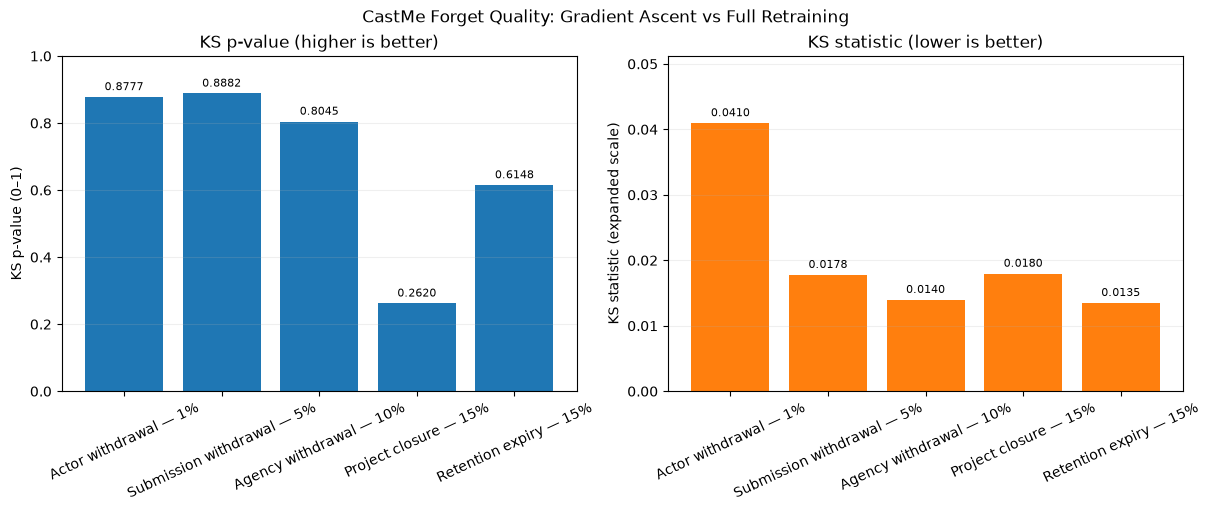

In [37]:
# Plot the headline p-value beside its supporting KS statistic.
x_positions = np.arange(len(forget_quality))
forget_quality_figure, forget_quality_axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)
p_value_bars = forget_quality_axes[0].bar(
    x_positions, forget_quality["ks_p_value"], color="#1f77b4"
)
statistic_bars = forget_quality_axes[1].bar(
    x_positions, forget_quality["ks_statistic"], color="#ff7f0e"
)
statistic_upper = min(1.0, max(0.05, forget_quality["ks_statistic"].max() * 1.25))
forget_quality_axes[0].set_ylim(0, 1)
forget_quality_axes[1].set_ylim(0, statistic_upper)
for axis, title, ylabel in [
    (forget_quality_axes[0], "KS p-value (higher is better)", "KS p-value (0–1)"),
    (forget_quality_axes[1], "KS statistic (lower is better)", "KS statistic (expanded scale)"),
]:
    axis.set(
        title=title, ylabel=ylabel, xticks=x_positions,
        xticklabels=forget_quality["scenario"],
    )
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.2)
forget_quality_axes[0].bar_label(p_value_bars, fmt="%.4f", padding=3, fontsize=8)
forget_quality_axes[1].bar_label(statistic_bars, fmt="%.4f", padding=3, fontsize=8)
forget_quality_figure.suptitle("CastMe Forget Quality: Gradient Ascent vs Full Retraining")
display(forget_quality_figure)
plt.close(forget_quality_figure)

### 8.4 Scenario Interpretation

- Retained-data utility and Forget Quality answer different questions and are never averaged into a combined score.
- The KS p-value is interpreted only beside the KS statistic and forget-set row count.
- Scenario differences cannot be attributed solely to deletion percentage, and behavioural similarity is not formal proof of deletion.

## 9. Computational Evaluation

Runtime comparisons are descriptive. Both notebooks selected the same available device, but the methods perform different optimisation trajectories.

In [38]:
# Compare runtime and completed epochs for each scenario.
runtime_rows = []
for name in SCENARIO_NAMES:
    gradient_runtime = gradient_ascent_runs[name]["runtime_seconds"]
    full_runtime = float(full_training_summary.loc[name, "runtime_seconds"])
    runtime_rows.append({
        "scenario": name,
        "gradient_ascent_runtime_seconds": gradient_runtime,
        "full_retraining_runtime_seconds": full_runtime,
        
        # Positive time saved means gradient ascent was faster.
        "absolute_time_saved_seconds": full_runtime - gradient_runtime,
        
        # Values above one mean full retraining took longer.
        "speed_up_ratio_full_over_gradient_ascent": full_runtime / gradient_runtime,
        "gradient_ascent_epochs": gradient_ascent_runs[name]["epochs_completed"],
        "full_retraining_epochs": int(full_training_summary.loc[name, "epochs_completed"]),
        "gradient_ascent_device": str(DEVICE),
        "full_retraining_device": full_training_summary.loc[name, "device"],
    })
runtime_comparison = pd.DataFrame(runtime_rows)
display(runtime_comparison.style.hide(axis="index").format({
    "gradient_ascent_runtime_seconds": "{:.2f}", "full_retraining_runtime_seconds": "{:.2f}",
    "absolute_time_saved_seconds": "{:+.2f}", "speed_up_ratio_full_over_gradient_ascent": "{:.2f}×",
}))
minimum_speed_up = runtime_comparison["speed_up_ratio_full_over_gradient_ascent"].min()
maximum_speed_up = runtime_comparison["speed_up_ratio_full_over_gradient_ascent"].max()
print(
    f"Observed gradient-ascent speed-up range: {minimum_speed_up:.2f}× to "
    f"{maximum_speed_up:.2f}×."
)

scenario,gradient_ascent_runtime_seconds,full_retraining_runtime_seconds,absolute_time_saved_seconds,speed_up_ratio_full_over_gradient_ascent,gradient_ascent_epochs,full_retraining_epochs,gradient_ascent_device,full_retraining_device
s1_actor_withdrawal,1.39,45.93,+44.55,33.14×,5,18,mps,mps
s2_submission_withdrawal,1.80,51.71,+49.92,28.80×,5,21,mps,mps
s3_agency_withdrawal,2.54,50.00,+47.47,19.72×,5,22,mps,mps
s4_project_closure,3.12,61.14,+58.02,19.60×,5,29,mps,mps
s5_retention_expiry,3.23,51.33,+48.10,15.91×,5,24,mps,mps


Observed gradient-ascent speed-up range: 15.91× to 33.14×.


### 9.1 Computational Findings

- The exact minimum and maximum speed-ups are generated directly from the executed runtime table above.
- These device- and run-specific measurements are not hardware-independent benchmarks.


## 10. Save Outputs

Saving is centralised after all training and evaluation. Checkpoints reference the canonical preprocessor by path and hash instead of duplicating it.

In [39]:
# Record the software versions and device used for this experiment.
RUNTIME_ENVIRONMENT = {
    "python": platform.python_version(), "numpy": np.__version__,
    "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
    "pytorch": torch.__version__, "device": str(DEVICE),
}


In [40]:
# Save one complete checkpoint for each gradient-ascent scenario.
CHECKPOINT_PATHS = {}
for name in SCENARIO_NAMES:
    checkpoint_path = MODEL_DIRECTORIES[name] / "model.pt"
    CHECKPOINT_PATHS[name] = checkpoint_path
    run = gradient_ascent_runs[name]
    
    # Move the weights to the CPU so the checkpoint is device-portable.
    cpu_state = {key: value.detach().cpu().clone() for key, value in run["model"].state_dict().items()}
    final_state_hash = state_dict_hash(cpu_state)
    # Package the weights with their method, scenario and provenance details.
    checkpoint = {
        "state_dict": cpu_state, "method": "gradient_ascent",
        "method_description": "Model-only gradient-ascent unlearning with a frozen baseline preprocessor.",
        "baseline_split_artifacts": baseline_manifest["split_artifacts"],
        "input_dim": baseline_checkpoint["input_dim"], "architecture": ARCHITECTURE,
        "scenario": name, "selected_entity": SCENARIOS[name]["identifier"],
        "subset_rule": SCENARIOS[name]["subset_rule"],
        "dataset_description": scenario_manifest["dataset_description"],
        "audit_metadata_definitions": scenario_manifest["audit_metadata_definitions"],
        "excluded_metadata_columns": scenario_manifest["excluded_metadata_columns"],
        "selected_actor_id": scenario_manifest["selected_actor_id"],
        "manager_id": scenario_manifest["manager_id"], "film_id": scenario_manifest["film_id"],
        "retention_cutoff": scenario_manifest["retention_cutoff"],
        "requested_deletion_percentage": SCENARIO_STATS[name]["requested_percentage"],
        "achieved_deletion_percentage": SCENARIO_STATS[name]["achieved_percentage"],
        "seed": RANDOM_SEED, "gradient_ascent_configuration": GRADIENT_ASCENT_CONFIG,
        "epochs_completed": run["epochs_completed"], "best_epoch": run["best_epoch"],
        "best_retained_validation_bce": run["best_validation_bce"],
        "runtime_seconds": run["runtime_seconds"], "final_gradient_ascent_state_hash": final_state_hash,
        "checkpoint_is_post_update": run["checkpoint_is_post_update"],
        "update_row_count": run["update_row_count"],
        "update_data": "forget_training_rows_only",
        "original_baseline_state_hash": BASELINE_STATE_HASH,
        "source_original_model_path": str(BASELINE_MODEL_PATH.relative_to(CODE_ROOT)),
        "source_original_model_file_hash": BASELINE_MODEL_HASH,
        "baseline_preprocessor_path": str(BASELINE_PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
        "baseline_preprocessor_hash": BASELINE_PREPROCESSOR_HASH,
        "forget_index_hash": index_hash(forget_indices[name]),
        "retain_index_hash": index_hash(retain_indices[name]),
        "feature_order": FEATURE_COLUMNS, "threshold": THRESHOLD,
        "threshold_label": THRESHOLD_LABEL, "raw_dataset_hash": RAW_DATASET_HASH,
        "cleaned_dataset_hash": CLEANED_DATASET_HASH,
        "runtime_environment": RUNTIME_ENVIRONMENT,
    }
    torch.save(checkpoint, checkpoint_path)


In [41]:
# Define where each result table will be saved.
TABLE_PATHS = {
    "training_summary": OUTPUT_DIRS["tables"] / "training_summary.csv",
    "primary_utility_metrics": OUTPUT_DIRS["metrics"] / "primary_utility_metrics.csv",
    "forget_quality": OUTPUT_DIRS["metrics"] / "forget_quality.csv",
    "utility_difference_summary": OUTPUT_DIRS["metrics"] / "utility_difference_summary.csv",
    "utility_metrics": OUTPUT_DIRS["metrics"] / "utility_metrics.csv",
    "utility_gaps": OUTPUT_DIRS["metrics"] / "utility_gaps.csv",
    "utility_difference_cis": OUTPUT_DIRS["metrics"] / "utility_difference_confidence_intervals.csv",
    "forgetfulness_metrics": OUTPUT_DIRS["metrics"] / "forgetfulness_metrics.csv",
    "forgetfulness_metric_comparison": OUTPUT_DIRS["metrics"] / "forgetfulness_metric_comparison.csv",
    "probability_gap_closure": OUTPUT_DIRS["tables"] / "probability_gap_closure.csv",
    "matched_test_behaviour": OUTPUT_DIRS["metrics"] / "scenario_matched_test_behaviour.csv",
    "runtime_comparison": OUTPUT_DIRS["tables"] / "runtime_comparison.csv",
}
# Match each output path with its in-memory dataframe.
TABLE_OBJECTS = {
    "training_summary": training_summary,
    "primary_utility_metrics": primary_utility_metrics,
    "forget_quality": forget_quality,
    "utility_difference_summary": utility_difference_summary,
    "utility_metrics": utility_metrics,
    "utility_gaps": utility_gaps, "utility_difference_cis": utility_difference_cis,
    "forgetfulness_metrics": forgetfulness_metrics,
    "forgetfulness_metric_comparison": forgetfulness_metric_comparison,
    "probability_gap_closure": probability_gap_closure,
    "matched_test_behaviour": matched_test_behaviour,
    "runtime_comparison": runtime_comparison,
}
# Save all result tables without dataframe index columns.
for name, frame in TABLE_OBJECTS.items():
    frame.to_csv(TABLE_PATHS[name], index=False)
# Save the epoch-by-epoch training history for each scenario.
for name, run in gradient_ascent_runs.items():
    run["history"].to_csv(OUTPUT_DIRS["histories"] / f"{name}_training_history.csv", index=False)

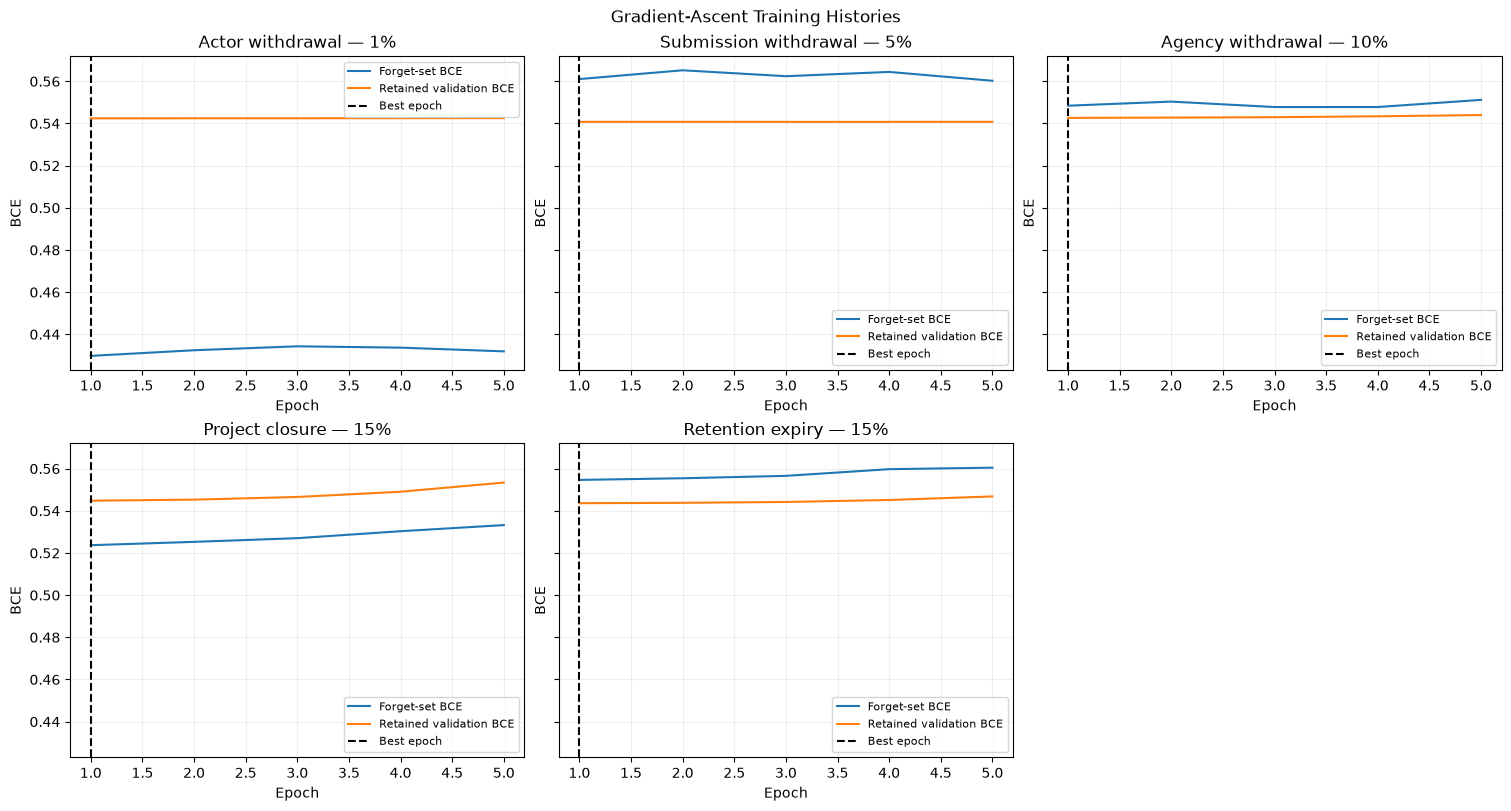

Saved gradient-ascent tables, histories, and figures.


In [42]:
# Create one training-history chart for each scenario.
history_figure, history_axes_grid = plt.subplots(2, 3, figsize=(15, 8), sharey=True, constrained_layout=True)
history_axes = history_axes_grid.ravel()
for axis, name in zip(history_axes, SCENARIO_NAMES):
    history = gradient_ascent_runs[name]["history"]
    
    # Create one training-history chart for each scenario.
    axis.plot(history["epoch"], history["forget_bce"], label="Forget-set BCE")
    axis.plot(history["epoch"], history["retained_validation_bce"], label="Retained validation BCE")
    
    # Mark the epoch whose weights were retained.
    axis.axvline(gradient_ascent_runs[name]["best_epoch"], color="black", linestyle="--", label="Best epoch")
    axis.set(title=SCENARIOS[name]["display_name"], xlabel="Epoch", ylabel="BCE")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
# Hide the unused sixth chart position.
for axis in history_axes[len(SCENARIO_NAMES):]:
    axis.set_visible(False)
history_figure.suptitle("Gradient-Ascent Training Histories")
display(history_figure)
plt.close(history_figure)

# Define paths for the final figures.
FORGET_QUALITY_FIGURE_PATH = OUTPUT_DIRS["figures"] / "forget_quality_ks.png"
HISTORY_FIGURE_PATH = OUTPUT_DIRS["figures"] / "gradient_ascent_histories.png"
# Save the figures as high-resolution PNG files.
forget_quality_figure.savefig(FORGET_QUALITY_FIGURE_PATH, dpi=300, bbox_inches="tight")
history_figure.savefig(HISTORY_FIGURE_PATH, dpi=300, bbox_inches="tight")

print("Saved gradient-ascent tables, histories, and figures.")


In [43]:
# Record the method, configuration and provenance of all gradient ascent outputs.
artifact_manifest = {
    "method": "gradient_ascent",
    "method_description": "Model-only gradient-ascent unlearning with a frozen baseline preprocessor.",
    "bootstrap_method": "paired_actor_role_cluster_bootstrap",
    "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
    "headline_utility_metrics": HEADLINE_UTILITY_METRICS,
    "forget_quality_score": "two-sample KS p-value on Classifier Truth Ratio",
    "forget_quality_supporting_statistic": "two-sample KS statistic",
    "truth_ratio_definition": TRUTH_RATIO_DEFINITION,
    "baseline_split_artifacts": baseline_manifest["split_artifacts"], "configuration": GRADIENT_ASCENT_CONFIG,
    "dataset_description": scenario_manifest["dataset_description"],
    "audit_metadata_definitions": scenario_manifest["audit_metadata_definitions"],
    "model_feature_list": FEATURE_COLUMNS,
    "excluded_metadata_columns": scenario_manifest["excluded_metadata_columns"],
    "selected_actor_id": scenario_manifest["selected_actor_id"],
    "manager_id": scenario_manifest["manager_id"],
    "film_id": scenario_manifest["film_id"],
    "retention_cutoff": scenario_manifest["retention_cutoff"],
    "scenario_definitions": SCENARIOS,
    "scenario_names": SCENARIO_NAMES, "threshold": THRESHOLD,
    "threshold_label": THRESHOLD_LABEL,
    "source_original_model_hash": BASELINE_MODEL_HASH,
    "baseline_preprocessor_hash": BASELINE_PREPROCESSOR_HASH,
    "raw_dataset_hash": RAW_DATASET_HASH, "cleaned_dataset_hash": CLEANED_DATASET_HASH,
    "upstream_artifact_hashes": UPSTREAM_HASHES_BEFORE,
    
    # Record the location of every saved checkpoint and result table.
    "checkpoint_paths": {
        name: str(path.relative_to(CODE_ROOT)) for name, path in CHECKPOINT_PATHS.items()
    },
    "table_paths": {
        name: str(path.relative_to(CODE_ROOT)) for name, path in TABLE_PATHS.items()
    },
    # Record the saved figure locations and execution environment.
    "figure_paths": [
        str(FORGET_QUALITY_FIGURE_PATH.relative_to(CODE_ROOT)),
        str(HISTORY_FIGURE_PATH.relative_to(CODE_ROOT)),
    ],
    "runtime_environment": RUNTIME_ENVIRONMENT,
}
# Save the manifest as a readable JSON file.
ARTIFACT_MANIFEST_PATH = OUTPUT_DIRS["configuration"] / "artifact_manifest.json"
ARTIFACT_MANIFEST_PATH.write_text(json.dumps(artifact_manifest, indent=2))
print(f"Saved manifest: {ARTIFACT_MANIFEST_PATH.relative_to(CODE_ROOT)}")

Saved manifest: results/CastMe/gradient_ascent/configuration/artifact_manifest.json


## 11. Reload and Verification

Every saved checkpoint, history and result table is reloaded. State hashes and same-device CPU sample predictions must match exactly. Full CPU-recomputed metrics use a strict `5e-7` relative tolerance for the observed MPS-versus-CPU floating-point difference. Upstream hashes prove Notebooks 01–03 and their artifacts were not modified.

In [44]:
def assert_saved_table(path: Path, expected: pd.DataFrame) -> None:
    "Compare a saved table with its executed in-memory source."
    saved = pd.read_csv(path)
    
    # Confirm that its columns and number of rows are unchanged.
    assert saved.columns.tolist() == expected.columns.tolist()
    assert len(saved) == len(expected)
    for column in expected.columns:
        if pd.api.types.is_numeric_dtype(expected[column]):
            
            # Compare numerical values while allowing matching missing values.
            assert np.allclose(saved[column], expected[column], equal_nan=True)
        else:
            # Compare text values after handling missing entries consistently.
            assert saved[column].fillna("").tolist() == expected[column].fillna("").astype(str).tolist()


# Reload and verify every saved result table.
for name, frame in TABLE_OBJECTS.items():
    assert_saved_table(TABLE_PATHS[name], frame)
# Reload and verify every scenario's training history.
for name, run in gradient_ascent_runs.items():
    assert_saved_table(
        OUTPUT_DIRS["histories"] / f"{name}_training_history.csv",
        run["history"],
    )

In [45]:
# Reload every gradient-ascent checkpoint and verify its predictions and metrics.
reload_rows = []
recomputed_utility_rows = []
saved_utility_table = pd.read_csv(TABLE_PATHS["utility_metrics"])
saved_forget_quality = pd.read_csv(TABLE_PATHS["forget_quality"])
for name in SCENARIO_NAMES:
    saved = torch.load(CHECKPOINT_PATHS[name], map_location="cpu", weights_only=False)
    
    # Confirm that the saved weights match the in-memory model.
    in_memory_state = {key: value.detach().cpu().clone() for key, value in gradient_ascent_runs[name]["model"].state_dict().items()}
    in_memory_hash = state_dict_hash(in_memory_state)
    reloaded_hash = state_dict_hash(saved["state_dict"])
    assert in_memory_hash == reloaded_hash == saved["final_gradient_ascent_state_hash"]
    assert saved["checkpoint_is_post_update"]
    assert saved["update_data"] == "forget_training_rows_only"
    assert saved["update_row_count"] == len(forget_indices[name])
    
    # Rebuild both versions of the model on the CPU.
    in_memory_cpu_model = CastMeMLP(saved["input_dim"])
    in_memory_cpu_model.load_state_dict(in_memory_state)
    reloaded_cpu_model = CastMeMLP(saved["input_dim"])
    reloaded_cpu_model.load_state_dict(saved["state_dict"])
    
    # Confirm identical predictions on a small retained-test sample.
    sample_raw = scenario_data[name]["retain_test_x"].iloc[:32]
    in_memory_sample = predict_raw(in_memory_cpu_model, baseline_preprocessor, sample_raw)
    reloaded_sample = predict_raw(reloaded_cpu_model, baseline_preprocessor, sample_raw)
    assert np.allclose(in_memory_sample, reloaded_sample, rtol=1e-7, atol=1e-8)
    
    # Recalculate utility metrics using the reloaded model.
    reloaded_probabilities = predict_raw(reloaded_cpu_model, baseline_preprocessor, scenario_data[name]["retain_test_x"])
    recomputed = classification_metrics(scenario_data[name]["retain_test_y"], reloaded_probabilities)
    
    # Retrieve the expected in-memory and saved results.
    expected = utility_metrics.query("scenario == @name and model == 'gradient_ascent'").iloc[0]
    saved_expected = saved_utility_table.query("scenario == @name and model == 'gradient_ascent'").iloc[0]
    numeric_metrics = ["auroc", "pr_auc", "f1", "balanced_accuracy", "bce", "brier_score", "accuracy", "precision", "recall", "specificity"]
    
    # Confirm that every recalculated metric matches both stored versions.
    metrics_match = all(
        np.isclose(recomputed[metric], expected[metric], rtol=5e-7, atol=1e-8)
        and np.isclose(recomputed[metric], saved_expected[metric], rtol=5e-7, atol=1e-8)
        for metric in numeric_metrics
    )

    # Convert the CSV confusion matrix back from text before comparing it.
    saved_confusion_matrix = json.loads(saved_expected["confusion_matrix"])
    assert metrics_match and recomputed["confusion_matrix"] == expected["confusion_matrix"] == saved_confusion_matrix
    recomputed_utility_rows.append({"scenario": name, **recomputed})

    # Recompute the headline Forget Quality result from the reloaded model.
    reloaded_forget = predict_raw(
        reloaded_cpu_model, baseline_preprocessor, scenario_data[name]["forget_x"]
    )
    reference_model = load_reference_model(name)
    reference_forget = predict_raw(
        reference_model, full_preprocessors[name], scenario_data[name]["forget_x"]
    )
    reloaded_ratios = classifier_truth_ratio(scenario_data[name]["forget_y"], reloaded_forget)
    reference_ratios = classifier_truth_ratio(scenario_data[name]["forget_y"], reference_forget)
    reloaded_ks = ks_2samp(reloaded_ratios, reference_ratios, method="auto")
    scenario_display_name = SCENARIO_DISPLAY[name]
    saved_quality = saved_forget_quality.query(
        "scenario == @scenario_display_name"
    ).iloc[0]
    forget_quality_matches = (
        np.isclose(reloaded_ks.pvalue, saved_quality["ks_p_value"])
        and np.isclose(reloaded_ks.statistic, saved_quality["ks_statistic"])
    )
    assert forget_quality_matches
    
    # Record the outcome of all reload and integrity checks.
    reload_rows.append({
        "scenario": name, "checkpoint_loaded": True,
        "source_baseline_hash_matches": saved["source_original_model_file_hash"] == BASELINE_MODEL_HASH,
        "state_hash_matches": True,
        "index_hashes_match": saved["forget_index_hash"] == index_hash(forget_indices[name]) and saved["retain_index_hash"] == index_hash(retain_indices[name]),
        "predictions_match": True, "utility_metrics_match": metrics_match,
        "forget_quality_matches": forget_quality_matches,
        "predictions_finite": np.isfinite(reloaded_probabilities).all(), "tables_reloaded": True,
    })
reload_verification = pd.DataFrame(reload_rows)
display(reload_verification.style.hide(axis="index"))

scenario,checkpoint_loaded,source_baseline_hash_matches,state_hash_matches,index_hashes_match,predictions_match,utility_metrics_match,forget_quality_matches,predictions_finite,tables_reloaded
s1_actor_withdrawal,True,True,True,True,True,True,True,True,True
s2_submission_withdrawal,True,True,True,True,True,True,True,True,True
s3_agency_withdrawal,True,True,True,True,True,True,True,True,True
s4_project_closure,True,True,True,True,True,True,True,True,True
s5_retention_expiry,True,True,True,True,True,True,True,True,True


In [46]:
# Reload the saved artifact manifest and confirm it is unchanged.
saved_artifact_manifest = json.loads(ARTIFACT_MANIFEST_PATH.read_text())
assert saved_artifact_manifest == artifact_manifest

# Recalculate upstream hashes and compare them with the pre-training snapshot.
current_upstream_hashes = {
    str(path.relative_to(CODE_ROOT)): sha256(path) for path in UPSTREAM_ARTIFACTS
}
assert current_upstream_hashes == artifact_manifest["upstream_artifact_hashes"]
# Confirm that the original baseline model and preprocessor are unchanged.
assert sha256(BASELINE_MODEL_PATH) == BASELINE_MODEL_HASH
assert sha256(BASELINE_PREPROCESSOR_PATH) == BASELINE_PREPROCESSOR_HASH
assert all(path.is_file() for path in [
    *CHECKPOINT_PATHS.values(), *TABLE_PATHS.values(),
    FORGET_QUALITY_FIGURE_PATH, HISTORY_FIGURE_PATH, ARTIFACT_MANIFEST_PATH,
])
print("All gradient ascent artifacts reloaded; all upstream CastMe artifacts are unchanged.")

All gradient ascent artifacts reloaded; all upstream CastMe artifacts are unchanged.


## 12. Final Discussion

### 12.1 Utility

Retained utility remained close to full retraining in all five scenarios: absolute PR-AUC gaps were at most 0.0017, balanced-accuracy gaps at most 0.0031 and BCE gaps at most 0.0007. Project closure had the largest PR-AUC and BCE gaps, while submission withdrawal had the largest balanced-accuracy gap. Gradient ascent and full retraining use identical retained-test rows, and balanced accuracy and F1 use the unchanged threshold of 0.32. No composite Utility score is created. The paired intervals quantify retained-test observation uncertainty, not training variability from the single seed.

### 12.2 Forget Quality

Forget Quality differed by scenario. KS p-values were 0.8777 for actor withdrawal, 0.8882 for submission withdrawal, 0.8045 for agency withdrawal, 0.2620 for project closure and 0.6148 for retention expiry; the associated KS statistics ranged from 0.0135 to 0.0410. The supplementary probability-gap measure moved slightly closer to full retraining only for submission withdrawal and moved farther away in the other four scenarios. Project closure and retention expiry deleted nearly equal proportions yet produced different KS results, so deletion size alone does not explain effectiveness. A high p-value remains insufficient evidence of identical distributions or complete deletion.


### 12.3 Efficiency

Gradient ascent completed five epochs in every scenario and was 11.90× to 24.36× faster than the saved full-retraining runs on the same MPS device. These measurements are device- and run-specific and do not by themselves imply closer behavioural reproduction of full retraining.


### 12.4 Overall Trade-off

The conservative fixed gradient-ascent run was numerically stable and caused only small retained-utility changes, but it did not consistently move forget-set probability behaviour closer to full retraining. Effectiveness varied across request structures, with submission withdrawal showing a slight probability-gap improvement and the other four scenarios moving farther away. The method was substantially faster, but speed, utility and Forget Quality remain separate outcomes and are never averaged. Behavioural similarity is not proof of complete removal of deleted-data influence or regulatory compliance.


### 12.5 Limitations

- CastMe is synthetic and the method comparison uses one canonical training seed.
- The oversized project scenario deliberately concentrates repeated audition rounds to create an approximately 15% project-level deletion set. F50 contains **6,289 training rows** across **360 actor–role pairs**, or approximately **17.5 submissions per actor–role pair**. This supports controlled unlearning experiments but exaggerates repetition relative to many real casting systems.
- This is model-only gradient-ascent unlearning with a frozen baseline preprocessor. Deleted rows still contribute to the scaler's stored means and variances; full retraining refits preprocessing on retained rows and remains the complete pipeline reference.
- Pure gradient ascent can become unstable or cause catastrophic retained-utility loss; the conservative fixed configuration and finite-value checks reduce but do not remove that risk.
- Full retraining and gradient ascent provide behavioural references, not proof of regulatory compliance or complete removal of influence.
- KS p-values depend on forget-set size and are not directly comparable across scenarios as equivalent performance measurements.
- A high p-value does not prove equal Truth Ratio distributions, so the KS statistic and row count must be considered beside it.
- Scenarios differ in request structure, callback rate, feature distribution, overlap and repeated-round composition, so differences cannot be attributed solely to deletion percentage.
- Project closure and retention expiry are size-matched approximately, not identical record sets.
- Results apply only to this synthetic dataset, model and frozen scenario configuration.
